# **Exercício Computacional: Regressão Linear e Regularização**

## Orientações
- Use apenas `numpy` e `matplotlib`
- Complete as partes indicadas
- Interprete os gráficos obtidos
- Responda às perguntas conceituais ao final

In [37]:
# Importando bibliotecas

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)



---

## Parte 1 — Geração de Dados

Considere o modelo:

$$
y = -\sin(x/5) + \cos(x) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, (0.2)^2)
$$


Para este modelo, pede-se

1. Gere um conjunto de treino com \(N=10\)
2. Gere um conjunto de teste com \(N=20\)
3. Considere $x \in [-5,5]$
4. Plote os dados de treino

In [38]:
# Defina aqui a função ``real'' do modelo (conforme enunciado)

def f_true(x):
    x = np.array(x) # garante que x seja um array numpy
    y = -np.sin(x / 5) + np.cos(x) # calcula os valores de y usando a função do enunciado
    return y

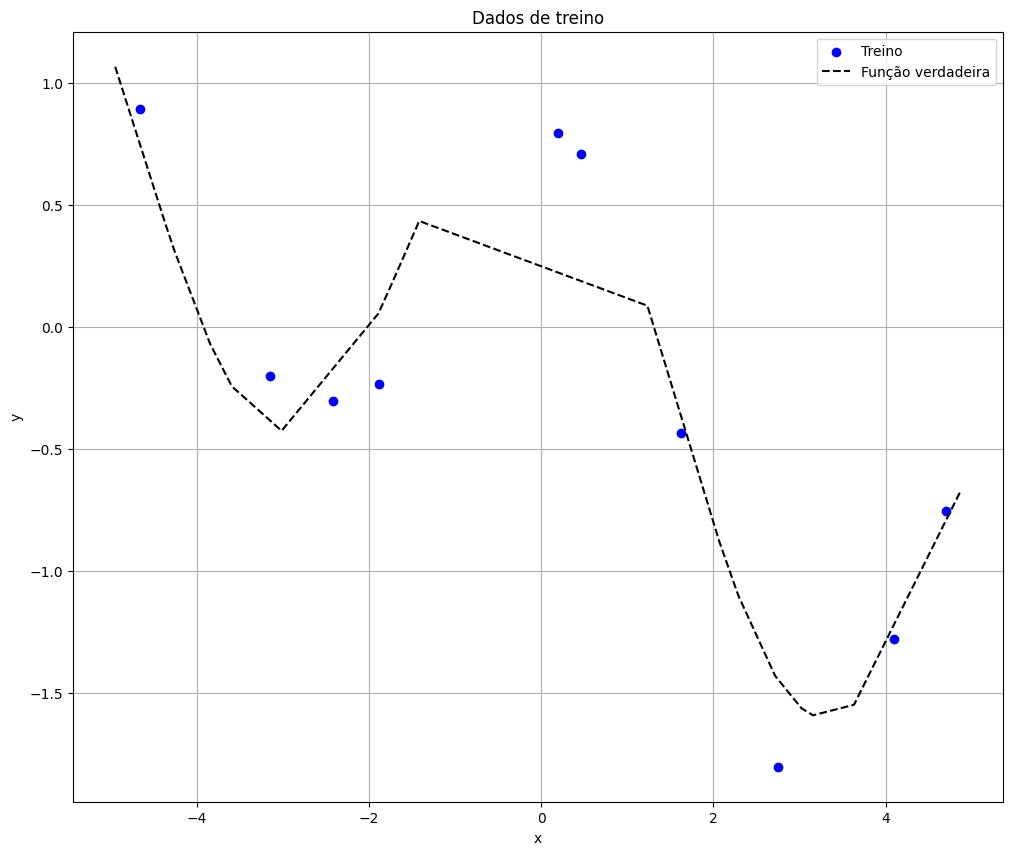

In [46]:
# Defina adequadamente a quantidade e os dados de treino e teste, utilizando a função f_true(x)

# Dados de treino
N_train = 10
x_train = np.random.uniform(-5, 5, N_train) # gera os valores de x de treino
y_train = f_true(x_train) + np.random.normal(0, 0.2, N_train) # gera os valores de y de treino com ruído conforme enunciado

# Dados de teste
N_test = 20
x_test = np.sort(np.random.uniform(-5, 5, N_test)) # gera os valores de x de teste
y_test = f_true(x_test) # gera os valores de y de teste sem ruído conforme enunciado

# Visualização
plt.figure(figsize=(12, 10))
plt.scatter(x_train, y_train, color='blue', label='Treino')
plt.plot(x_test, y_test, color='black', linestyle='--', label='Função verdadeira')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Dados de treino')
plt.legend()
plt.grid(True)
plt.show()

## Parte 2 — Regressão Polinomial por MLE e Ridge

Considere as features:

$$\boldsymbol{\phi}(x) = [1, x, x^2, \dots, x^M]$$

e os estimadores:

$$\theta_{ML} = (\Phi^\top \Phi)^{-1}\Phi^\top y$$

$$
\theta_{Ridge} = (\Phi^\top \Phi + \lambda I)^{-1}\Phi^\top y
$$

Para auxiliar na implementação da regressão, implemente as seguintes funções auxiliares:
1. a matriz de features polinomiais
2. o estimador MLE
3. o estimador Ridge (LS com regularização quadrática)
4. a métrica RMSE

In [40]:
# função que cria a matriz que contém, em cada linha, as potências de x, i.e., [1 x x^2 x^3 ... x^M]
def phi(x, M):
    x = np.asarray(x).reshape(-1) # garante que x seja um array numpy de uma dimensão
    Phi = np.column_stack([x**i for i in range(M + 1)]) # cria a matriz de características com as potências de x
    return Phi

# função que obtém o estimador MLE
def mle(Phi, y):
    return np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y # calcula o estimador MLE usando a fórmula do enunciado

# função que obtém o estimador de mínimos quadrados com regularização quadrática (parâmetro lam de regularização)
def ridge(Phi, y, lam):
    ridge = Phi.T @ Phi + lam * np.eye(Phi.shape[1]) # calcula a matriz de regularização
    return np.linalg.solve(ridge, Phi.T @ y) # calcula o estimador de mínimos quadrados com regularização quadrática usando a fórmula do enunciado

# função que estima o rmse entre os valores preditos e os verdadeiros
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2)) # calcula o RMSE



## Parte 3 — Teste da Regressão Polinomial por MLE

Utilizando as funções já implementadas:
1. Ajuste modelos para $M = 0,1,\dots,9$
2. Calcule RMSE de treino e teste
3. Plote:
   - as curvas ajustadas
   - RMSE em função do grau

In [41]:
# Insira seu código referente aos itens 1. e 2.
graus = range(10) # graus dos polinômioS
rmse_train_mle = [] # armazenar os RMSEs do MLE
rmse_test_mle = [] # armazenar os RMSEs do MLE
thetas_mle = [] # armazenar os parâmetros do MLE

for M in graus:
    Phi_train = phi(x_train, M) # matriz de características de treino
    Phi_test = phi(x_test, M) # matriz de características de teste
    
    theta_mle = mle(Phi_train, y_train) # obtém o estimador MLE
    thetas_mle.append(theta_mle) # armazena os parâmetros MLE
    
    y_pred_train_mle = Phi_train @ theta_mle # predições de treino usando o MLE
    y_pred_test_mle = Phi_test @ theta_mle # predições de teste usando o MLE
    
    rmse_train_mle.append(rmse(y_train, y_pred_train_mle)) # calcula e armazena o RMSE de treino do MLE
    rmse_test_mle.append(rmse(y_test, y_pred_test_mle)) # calcula e armazena o RMSE de teste do MLE 

# Loop para imprimir os resultados
for M in graus:
    print(f"Grau {M}: RMSE Treino = {rmse_train_mle[M]:.4f}, RMSE Teste = {rmse_test_mle[M]:.4f}")





Grau 0: RMSE Treino = 0.6695, RMSE Teste = 0.8916
Grau 1: RMSE Treino = 0.5577, RMSE Teste = 0.7610
Grau 2: RMSE Treino = 0.4813, RMSE Teste = 0.6478
Grau 3: RMSE Treino = 0.4692, RMSE Teste = 0.6341
Grau 4: RMSE Treino = 0.1172, RMSE Teste = 0.2311
Grau 5: RMSE Treino = 0.1168, RMSE Teste = 0.2332
Grau 6: RMSE Treino = 0.1056, RMSE Teste = 0.1883
Grau 7: RMSE Treino = 0.1006, RMSE Teste = 0.9394
Grau 8: RMSE Treino = 0.1005, RMSE Teste = 0.4710
Grau 9: RMSE Treino = 0.1004, RMSE Teste = 0.8118


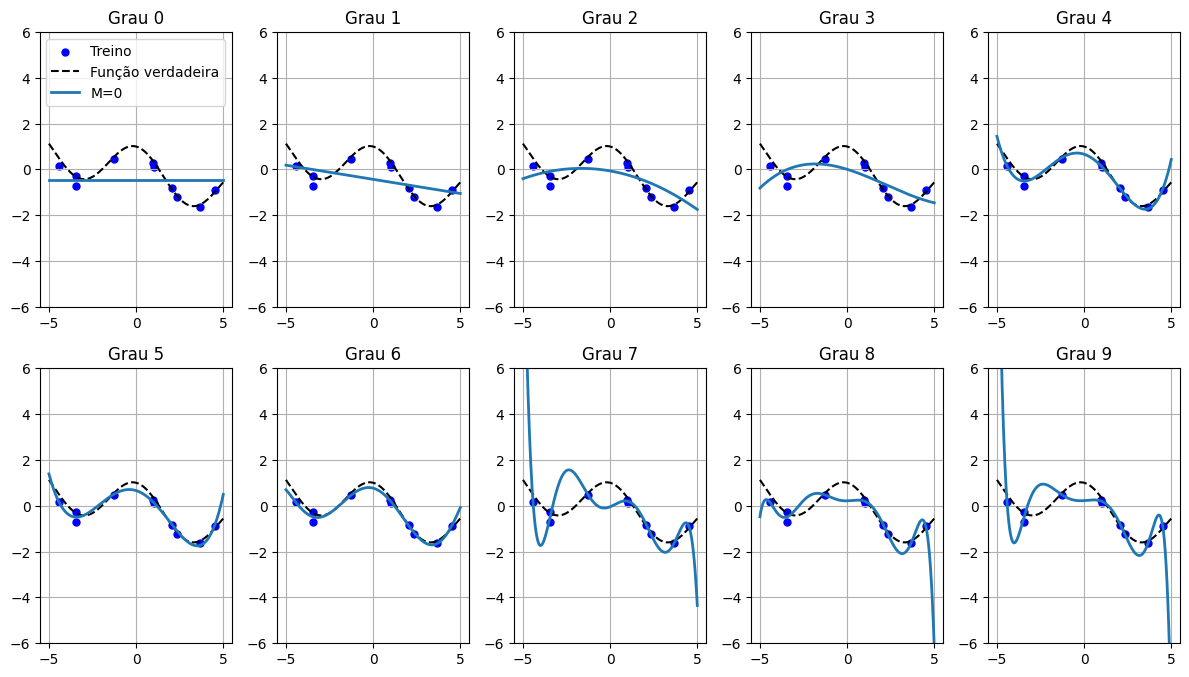

In [42]:
# Insira seu código para plotar as curvas ajustadas
x_grid = np.linspace(-5, 5, 400) # gera um grid de valores de x 

plt.figure(figsize=(12, 10)) 

# Loop para plotar as curvas ajustadas para cada grau M
for i, M in enumerate(graus):
    plt.subplot(3, 5, i + 1)

    y_grid = phi(x_grid, M) @ thetas_mle[i] # calcula as predições para o grid usando os parâmetros MLE

    plt.scatter(x_train, y_train, color='blue', s=25, label='Treino')
    plt.plot(x_grid, f_true(x_grid), 'k--', linewidth=1.5, label='Função verdadeira')
    plt.plot(x_grid, y_grid, linewidth=2, label=f'M={M}')

    plt.title(f'Grau {M}')
    plt.ylim(-6, 6)
    plt.grid(True)

    if i == 0:
        plt.legend(loc = 'upper right')

plt.tight_layout()
plt.show()

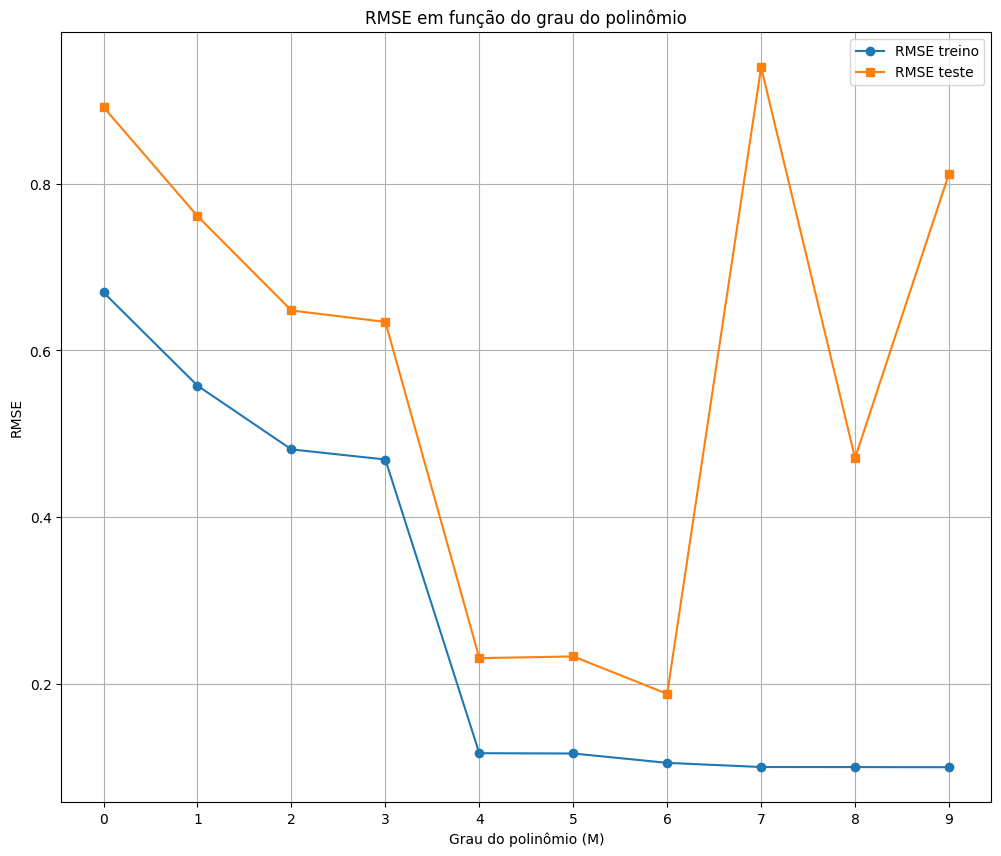

In [43]:
# Insira seu código para plotar a curva de RMS em função do grau (tanto treino, como teste)
plt.figure(figsize=(12, 10)) 
plt.plot(list(graus), rmse_train_mle, marker='o', label='RMSE treino')
plt.plot(list(graus), rmse_test_mle, marker='s', label='RMSE teste')
plt.xlabel('Grau do polinômio (M)')
plt.ylabel('RMSE')
plt.title('RMSE em função do grau do polinômio')
plt.xticks(list(graus))
plt.grid(True)
plt.legend()
plt.show()

## Parte 4 — Overfitting

Responda:

1. Por que o erro de treino tende a diminuir quando o grau do polinômio aumenta?
2. Por que o erro de teste pode aumentar para graus altos?
3. Em qual faixa de graus há sinais de overfitting?
4. Qual grau parece oferecer melhor generalização?

Justifique suas respostas

Respostas:

1.  O erro de treino tende a diminuir porque, ao aumentar o grau do polinômio, o modelo ganha mais flexibilidade e passa a ter maior capacidade de se ajustar aos pontos observados no conjunto de treino, inclusive ao ruído, o que acaca comprometendo o desempenho do modelo em modelos muito flexiveis (i.e., elevado grau do polinômio). 

2. O erro de teste pode aumentar para graus altos porque o modelo passa a se ajustar excessivamente aos dados de treinamento. Esse ajuste exagerado reduz a capacidade de previsão do modelo, fazendo com que o desempenho em dados não observados (conjunto de teste) piore, ou seja, piora a generalização.

3. Há sinais de overfitting nos graus mais altos, especialmente a partir de M = 7, quando o RMSE de treino permanece baixo, mas o RMSE de teste cresce de forma acentuada.

4. A melhor generalização acontece no grau 6 (M = 6),








## Parte 5 — Regularização Ridge

Para o estimador com Ridge regression, pede-se
### Tarefas
1. Fixe $M=9$
2. Teste:
   $\lambda = 0,\ 10^{-3},\ 10^{-1},\ 1,\ 10$
3. Compare as curvas ajustadas
4. Compare RMSE de treino e teste

In [44]:
# Insira seu código aqui para comparação das curvas ajustadas







In [45]:
# Insira seu códivo aqui para a comparação do RMSE de treino e teste









## Parte 6 — Relação entre Ridge e MAP

Sabemos que, para prior Gaussiano $p(\theta) = \mathcal{N}(0, b^2 I)$

a estimativa MAP leva à solução

$
\theta_{MAP} = (\Phi^\top \Phi + \lambda I)^{-1}\Phi^\top y
$

com

$
\lambda = \frac{\sigma^2}{b^2}
$

Responda:

1. Qual o efeito de escolher um valor grande de \(\lambda\)?
2. Qual o efeito de escolher uma variância \(b^2\) pequena no prior?
3. Por que a regularização ajuda a reduzir overfitting?
4. Em que sentido Ridge pode ser interpretado como MAP?

Respostas:

1.



2.



3.



4.










# Parte 7 - Conclusões

Responda de forma objetiva:

1. Qual a principal limitação da estimativa por máxima verossimilhança?
2. Por que polinômios de grau alto podem ajustar bem o treino e mal o teste?
3. Qual a diferença prática entre MLE e Ridge?
4. Como o parâmetro $\lambda$ afeta a complexidade do modelo?
5. O que acontece com o modelo quando $\lambda \to \infty$?

Respostas:

1.


2.


3.


4.


5.